# Math for ML — Linear Algebra & Calculus Intuition
### Week 5–6 Hack-o-Week | ArpitaBuilds

This notebook covers the math you actually need for ML — no proofs, all intuition + code.
Every section ties back to your **Explainable AI Stroke Risk** project (XGBoost + SHAP), so this isn't
random theory, it's the "why" behind the model you're building.

**Covers:** vectors, matrices, dot product, eigenvalues → derivatives, gradients, chain rule

**Why it matters for your project:**
- Your patient records = vectors (age, BP, glucose, BMI...)
- XGBoost = literally short for "e**X**treme **G**radient Boosting" — it trains by computing gradients of a loss function
- SHAP values = built on top of these same gradient/attribution ideas
- If you ever add a neural net baseline to compare against XGBoost, chain rule = backprop


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.grid'] = True
print("Setup done ✅")

Setup done ✅


---
## 1. Vectors

A vector is just a **list of numbers with a direction and magnitude**. In ML, every data point is a vector.

Example: one patient in your stroke dataset might look like `[age=65, bp=140, glucose=180, bmi=27]` — that's a 4D vector.
We can't draw 4D, so let's build intuition in 2D first.

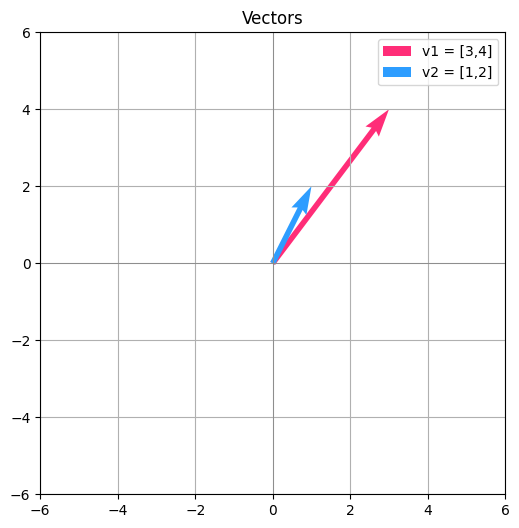

Magnitude of v1: 5.0
v1 + v2 = [4 6]


In [2]:
# A vector = arrow from origin to a point
v1 = np.array([3, 4])
v2 = np.array([1, 2])

def plot_vectors(vectors, colors, labels, title="Vectors"):
    fig, ax = plt.subplots()
    for v, c, l in zip(vectors, colors, labels):
        ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color=c, label=l, width=0.012)
    lim = max(abs(np.array(vectors)).max(), 1) + 2
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.legend(); ax.set_title(title)
    plt.show()

plot_vectors([v1, v2], ['#ff2d78', '#2d9dff'], ['v1 = [3,4]', 'v2 = [1,2]'])

# Magnitude (length) of a vector
print("Magnitude of v1:", np.linalg.norm(v1))   # sqrt(3^2 + 4^2) = 5
# Vector addition
print("v1 + v2 =", v1 + v2)

**Key takeaway:** magnitude = `sqrt(sum of squares)`. This is the same formula used to compute distance
between two patients' feature vectors (useful for similarity-based explanations).

---
## 2. Dot Product

`dot(a, b) = a1*b1 + a2*b2 + ... + an*bn`

Geometric meaning: **how much two vectors point in the same direction.**
- Large positive → vectors point similarly
- 0 → perpendicular (no relationship)
- Negative → point in opposite directions

This is literally what a **neuron does**: `output = dot(weights, inputs) + bias`. Every layer of a neural
network (and even linear/logistic regression) is dot products stacked on top of each other.

In [3]:
a = np.array([3, 4])
b = np.array([1, 2])

dot = np.dot(a, b)
cos_angle = dot / (np.linalg.norm(a) * np.linalg.norm(b))
angle_deg = np.degrees(np.arccos(cos_angle))

print(f"dot(a,b) = {dot}")
print(f"angle between them = {angle_deg:.1f}°")

# ML angle: cosine similarity is dot product normalized -> used to compare feature vectors / embeddings
def cosine_similarity(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

patient_1 = np.array([65, 140, 180, 27])   # age, bp, glucose, bmi
patient_2 = np.array([70, 150, 190, 29])
patient_3 = np.array([20, 110, 90, 21])

print("\nSimilarity patient1-patient2 (both high risk profile):", round(cosine_similarity(patient_1, patient_2), 3))
print("Similarity patient1-patient3 (very different profile): ", round(cosine_similarity(patient_1, patient_3), 3))

dot(a,b) = 11
angle between them = 10.3°

Similarity patient1-patient2 (both high risk profile): 1.0
Similarity patient1-patient3 (very different profile):  0.967


**Connects to your project:** this is exactly the kind of feature-vector comparison you could use to explain
"this patient is high-risk because they resemble other high-risk patients."

---
## 3. Matrices

A matrix is a **transformation** — it takes a vector in and spits a new (rotated/scaled/skewed) vector out.
`Matrix @ vector = new vector`

In ML: every layer's weights are a matrix. `output = W @ x + b` is a linear transformation of your input.

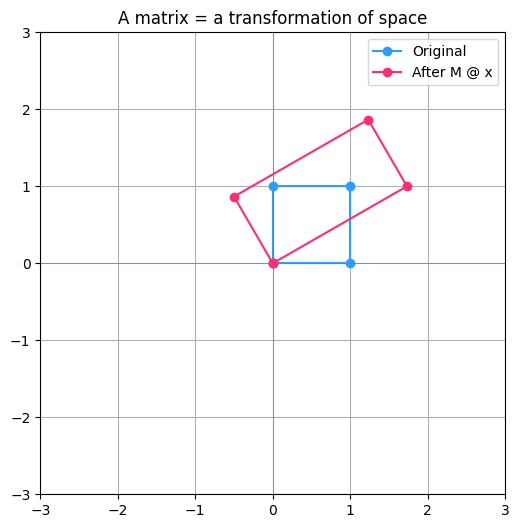

Matrix M:
 [[ 1.73205081 -0.5       ]
 [ 1.          0.8660254 ]]


In [4]:
# A matrix that stretches x by 2 and rotates a bit
theta = np.radians(30)
M = np.array([
    [2*np.cos(theta), -np.sin(theta)],
    [2*np.sin(theta),  np.cos(theta)]
])

square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T   # unit square corners
transformed = M @ square

fig, ax = plt.subplots()
ax.plot(square[0], square[1], 'o-', color='#2d9dff', label='Original')
ax.plot(transformed[0], transformed[1], 'o-', color='#ff2d78', label='After M @ x')
ax.set_xlim(-3,3); ax.set_ylim(-3,3)
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.legend(); ax.set_title("A matrix = a transformation of space")
plt.show()

print("Matrix M:\n", M)

**Key takeaway:** every "layer" in a model (linear regression, a dense NN layer, even the linear
part of a logistic regression used as an XGBoost leaf estimator) is just: **matrix transforms your
feature vector into a new space where the decision becomes easier to make.**

---
## 4. Eigenvalues & Eigenvectors (intuition only)

For most vectors, `M @ v` changes both the direction and length of `v`.
But for special vectors — **eigenvectors** — the matrix only *stretches/shrinks* them, it never
changes their direction. The stretch factor is the **eigenvalue**.

`M @ v = λ * v`

**Why you care:** PCA (a common dimensionality-reduction technique) finds the eigenvectors of your
data's covariance matrix — these are the directions of maximum variance/information in your dataset.
If you ever reduce your stroke dataset's features before training, this is what's happening under the hood.

Eigenvalues: [3. 1.]
Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


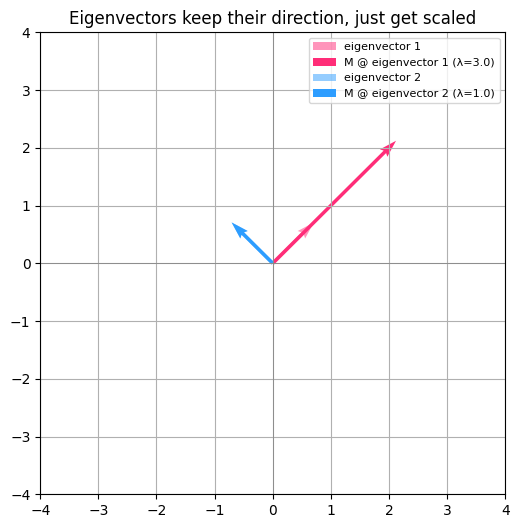

In [5]:
M = np.array([[2, 1],
              [1, 2]])

eigenvalues, eigenvectors = np.linalg.eig(M)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

# Visualize: eigenvectors don't change direction after transformation
fig, ax = plt.subplots()
colors = ['#ff2d78', '#2d9dff']
for i in range(2):
    v = eigenvectors[:, i]
    Mv = M @ v
    ax.quiver(0,0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color=colors[i], alpha=0.5,
              label=f'eigenvector {i+1}')
    ax.quiver(0,0, Mv[0], Mv[1], angles='xy', scale_units='xy', scale=1, color=colors[i],
              label=f'M @ eigenvector {i+1} (λ={eigenvalues[i]:.1f})')
ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.legend(fontsize=8); ax.set_title("Eigenvectors keep their direction, just get scaled")
plt.show()

---
## 5. Derivatives

A derivative = **rate of change** = slope of a function at a point.
`f'(x)` tells you: if I nudge x a tiny bit, how much does f(x) move?

In ML, this is how a model learns: the derivative of the **loss function** with respect to a
parameter tells us which direction to adjust that parameter to reduce error.

f(x)     = x**2 + 3*x + 5
f'(x)    = 2*x + 3
slope at x=2: 7


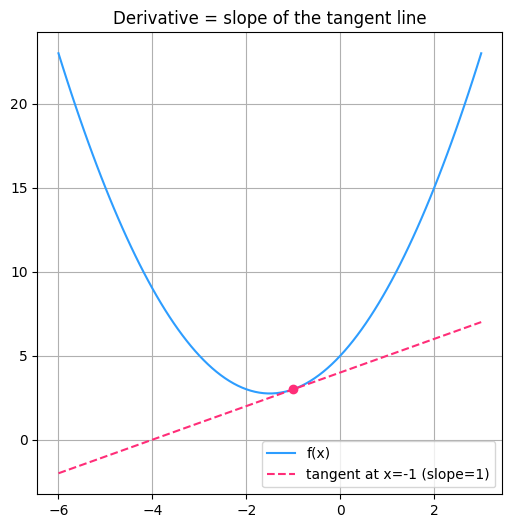

In [6]:
import sympy as sp

x = sp.Symbol('x')
f = x**2 + 3*x + 5           # a simple loss-like function
f_prime = sp.diff(f, x)
print("f(x)     =", f)
print("f'(x)    =", f_prime)
print("slope at x=2:", f_prime.subs(x, 2))

# Visualize
xs = np.linspace(-6, 3, 100)
f_np = sp.lambdify(x, f, 'numpy')
fprime_np = sp.lambdify(x, f_prime, 'numpy')

point = -1
tangent_slope = fprime_np(point)
tangent_line = f_np(point) + tangent_slope * (xs - point)

fig, ax = plt.subplots()
ax.plot(xs, f_np(xs), color='#2d9dff', label='f(x)')
ax.plot(xs, tangent_line, '--', color='#ff2d78', label=f'tangent at x={point} (slope={tangent_slope})')
ax.scatter([point], [f_np(point)], color='#ff2d78', zorder=5)
ax.legend(); ax.set_title("Derivative = slope of the tangent line")
plt.show()

---
## 6. Gradients & Gradient Descent

A **gradient** is just derivatives for a function with *multiple* inputs — one partial derivative per
input, packed into a vector. It points in the direction of **steepest increase**.

To minimize a loss function, we step in the **opposite** direction of the gradient, repeatedly.
This is literally the training loop of every gradient-based ML model — including the "Gradient" in
**XGBoost = eXtreme Gradient Boosting.**

Path toward minimum (first 5 steps):
 [[4.     3.    ]
 [2.4    1.8   ]
 [1.44   1.08  ]
 [0.864  0.648 ]
 [0.5184 0.3888]]
Final point (should be near [0,0]): [0.00188074 0.00141055]


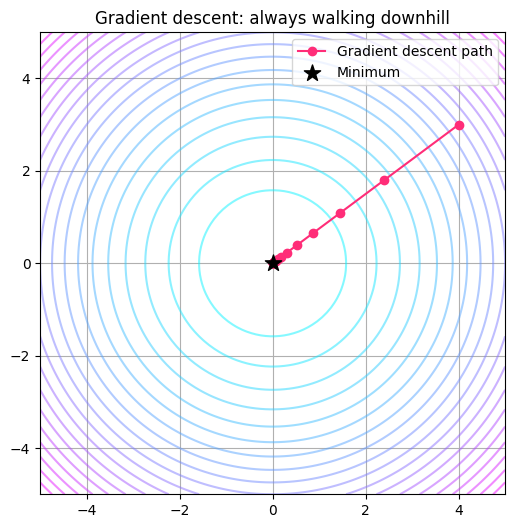

In [7]:
# Minimize f(x,y) = x^2 + y^2 (a bowl-shaped loss surface) using gradient descent
def f(x, y): return x**2 + y**2
def grad_f(x, y): return np.array([2*x, 2*y])   # partial derivatives

point = np.array([4.0, 3.0])   # start far from the minimum
lr = 0.2
path = [point.copy()]

for step in range(15):
    g = grad_f(*point)
    point = point - lr * g       # step opposite the gradient
    path.append(point.copy())

path = np.array(path)
print("Path toward minimum (first 5 steps):\n", path[:5])
print("Final point (should be near [0,0]):", path[-1])

# Visualize the descent on a contour plot
xs = np.linspace(-5, 5, 100)
ys = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

fig, ax = plt.subplots()
ax.contour(X, Y, Z, levels=20, cmap='cool', alpha=0.5)
ax.plot(path[:,0], path[:,1], 'o-', color='#ff2d78', label='Gradient descent path')
ax.scatter([0],[0], color='black', marker='*', s=150, label='Minimum', zorder=5)
ax.legend(); ax.set_title("Gradient descent: always walking downhill")
plt.show()

**Direct connection to your project:** XGBoost builds trees one at a time, and each new tree is
trained to fit the **gradient of the loss** from the previous trees (with a second-order Hessian term too —
that's the "extreme" in extreme gradient boosting). You just watched the exact mechanism above, in 2D.

---
## 7. Chain Rule (→ Backpropagation Intuition)

If `y = f(g(x))`, the chain rule says:
`dy/dx = dy/dg * dg/dx`

You differentiate the "outer" function and multiply by the derivative of the "inner" function.
This is **the entire mathematical trick behind backpropagation** in neural networks — a network is just
a long chain of composed functions, and the chain rule lets you compute how a change in any early
weight affects the final loss, layer by layer, backward.

In [8]:
# Manual chain rule check with sympy
x = sp.Symbol('x')
inner = 2*x + 1          # g(x)
outer_expr = inner**2    # f(g) = g^2  ->  y = (2x+1)^2

dy_dx = sp.diff(outer_expr, x)
print("y = (2x+1)^2")
print("dy/dx (sympy, direct) =", dy_dx)

# now manually via chain rule: dy/dg * dg/dx
g = sp.Symbol('g')
f_of_g = g**2
dy_dg = sp.diff(f_of_g, g).subs(g, inner)   # 2g -> 2(2x+1)
dg_dx = sp.diff(inner, x)                    # 2
chain_result = sp.expand(dy_dg * dg_dx)
print("dy/dx (chain rule: dy/dg * dg/dx) =", chain_result)

y = (2x+1)^2
dy/dx (sympy, direct) = 8*x + 4
dy/dx (chain rule: dy/dg * dg/dx) = 8*x + 4


In [9]:
# Tiny 1-neuron "network" forward + backward pass -- this IS backprop
w, b = 0.5, 0.1          # weight, bias
x_input, y_true = 2.0, 1.0

# forward pass
z = w * x_input + b               # linear step
a = 1 / (1 + np.exp(-z))          # sigmoid activation
loss = 0.5 * (a - y_true)**2      # squared error loss

# backward pass -- chain rule, one link at a time
dloss_da = (a - y_true)
da_dz = a * (1 - a)               # derivative of sigmoid
dz_dw = x_input

dloss_dw = dloss_da * da_dz * dz_dw   # <-- chain rule in action
dloss_db = dloss_da * da_dz * 1

print(f"forward: z={z:.4f}, a={a:.4f}, loss={loss:.4f}")
print(f"gradient w.r.t weight (dloss/dw) = {dloss_dw:.4f}")
print(f"gradient w.r.t bias   (dloss/db) = {dloss_db:.4f}")
print("\n^ this exact chained multiplication is what PyTorch/TensorFlow automate for you as .backward()")

forward: z=1.1000, a=0.7503, loss=0.0312
gradient w.r.t weight (dloss/dw) = -0.0936
gradient w.r.t bias   (dloss/db) = -0.0468

^ this exact chained multiplication is what PyTorch/TensorFlow automate for you as .backward()


---
## Recap Cheat Sheet

| Concept | One-line intuition | Where it shows up in your project |
|---|---|---|
| Vector | A data point / feature list | Each patient record |
| Dot product | How aligned two vectors are | Similarity between patients, core of every neuron |
| Matrix | A transformation of space | Model weights, PCA, layer transforms |
| Eigenvalue/vector | Directions a transform doesn't rotate, just scales | PCA / dimensionality reduction |
| Derivative | Rate of change / slope | How loss changes as one parameter moves |
| Gradient | Derivative for many variables at once | Direction XGBoost/NNs step to reduce error |
| Chain rule | Derivative of a composed function | Backpropagation, layer-by-layer |

## Self-check (try before moving on)
1. Why does XGBoost have "Gradient" in its name?
2. If two feature vectors have a dot product of 0, what does that mean geometrically?
3. What's the difference between a derivative and a gradient?
4. In the 1-neuron example above, why do we multiply `dloss_da * da_dz * dz_dw` instead of adding them?

## Next step
Open the companion **React visualizer** (ArpitaBuilds) to *drag and see* these concepts interactively —
vectors, matrix transforms, gradient descent, and the mini backprop chain, all live.
